# SC5006 Project 1 — CountGD Component Analysis and Open-World Counting

**Team size:** 1–5 students  
**Foundation model:** [CountGD](https://github.com/niki-amini-naieni/CountGD), NeurIPS 2024  
**Test images:** `women.jpg` and `car.jpg`  
**Required evidence:** component shapes/visualizations, live-model predictions, quantitative results, and failure analysis

The project studies five linked CountGD components. A five-person team should assign one primary owner to each component; smaller teams combine roles. Every member must understand the integrated pipeline and speak during the oral presentation.

| Role | Assessed component | Main evidence |
|---|---|---|
| A | Image encoder | multi-scale features and combined 1/8-scale feature map |
| B | Text encoder | tokenization, masks, and projected BERT tokens |
| C | ROIAlign | pixel-space exemplar box and extracted visual token |
| D | Similarity matrix | query–prompt logits and padding mask |
| E | Top-K selection | ranked encoder proposals and prompt IDs |

The shared integration experiment runs the official CountGD checkpoint on women (text prompt) and cars (text-only, exemplar-only, and multimodal prompts), then applies the official confidence threshold and counting rule.

## Deliverables

Submit three files named with your team name:

1. `TeamXX_SC5006_Project1.ipynb` — completed code, outputs, plots, and brief interpretations.
2. `TeamXX_SC5006_Project1_Report.pdf` — Title, Authors, Introduction, Related Work, Method, Experiments, Results and Discussion, Conclusion, References, and contribution statement.
3. `TeamXX_SC5006_Project1_Presentation.pptx` — a 10-minute oral presentation; 1-2 members do the presentation; but all members must join the Q&A.

The report should be 6–8 pages excluding references/appendix. The presentation should contain 8–15 content slides. Results must distinguish live-model evidence from cached reference outputs.


## 0. Environment and model setup

Run the cell below from the project folder. It downloads the official CountGD FSC-147 checkpoint and BERT encoder only when missing, verifies the checkpoint SHA-256, loads all model weights, and prints the active paths and device. Internet access is needed only for the first run.


In [1]:
import sys
import transformers
import subprocess

print("Python:", sys.executable)
print("Loaded transformers:", transformers.__version__)
print("Loaded from:", transformers.__file__)

print("\nPip sees:")
subprocess.run([
    sys.executable, "-m", "pip", "show", "transformers"
])


Python: C:\Education\SOFTWARE\python.exe
Loaded transformers: 4.40.2
Loaded from: C:\Education\SOFTWARE\Lib\site-packages\transformers\__init__.py

Pip sees:


CompletedProcess(args=['C:\\Education\\SOFTWARE\\python.exe', '-m', 'pip', 'show', 'transformers'], returncode=0)

In [2]:
import transformers
print(transformers.__version__)

4.40.2


In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
import sys
import transformers

print("Python:", sys.executable)
print("Transformers:", transformers.__version__)
print("Location:", transformers.__file__)


Python: C:\Education\SOFTWARE\python.exe
Transformers: 4.40.2
Location: C:\Education\SOFTWARE\Lib\site-packages\transformers\__init__.py


In [5]:
import transformers
from transformers import BertModel

print("Transformers version:", transformers.__version__)
print("Has get_extended_attention_mask:",
      hasattr(BertModel, "get_extended_attention_mask"))

Transformers version: 4.40.2
Has get_extended_attention_mask: True


In [6]:
from pathlib import Path
import hashlib, importlib, os, subprocess, sys, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import torch
import torch.nn.functional as F

warnings.filterwarnings("ignore")

# Open the notebook from the distributed project folder.
ROOT = Path.cwd().resolve()
if not (ROOT / "assets/reference/car.jpg").is_file():
    raise FileNotFoundError("Open this notebook from the Project 1 folder.")

ASSETS = ROOT / "assets/reference"
OUTPUT = ROOT / "output/figures"
CHECKPOINTS = ROOT / "checkpoints"
CHECKPOINT = CHECKPOINTS / "checkpoint_fsc147_best.pth"
BERT = CHECKPOINTS / "bert-base-uncased"
COUNTGD_ROOT = ROOT / "vendor/countgd"
OUTPUT.mkdir(parents=True, exist_ok=True)
CHECKPOINTS.mkdir(parents=True, exist_ok=True)

CHECKPOINT_FILE_ID = "1RbRcNLsOfeEbx6u39pBehqsgQiexHHrI"
EXPECTED_CHECKPOINT_SHA256 = "c1bab864b17db345b4c6e3aaabb5765bc2c0a90d0bc8defb5e664a74a50aa126"

def require_package(module, package=None):
    try:
        return importlib.import_module(module)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package or module])
        return importlib.import_module(module)

def download_missing_assets():
    if not CHECKPOINT.is_file():
        print("Downloading the official CountGD FSC-147 checkpoint (1.2 GB)...")
        gdown = require_package("gdown")
        result = gdown.download(id=CHECKPOINT_FILE_ID, output=str(CHECKPOINT), quiet=False)
        if not result or not CHECKPOINT.is_file():
            raise RuntimeError("Official CountGD checkpoint download failed.")
    if not (BERT / "config.json").is_file():
        print("Downloading the official BERT base encoder...")
        huggingface_hub = require_package("huggingface_hub")
        huggingface_hub.snapshot_download(
            repo_id="google-bert/bert-base-uncased", local_dir=str(BERT)
        )

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

download_missing_assets()
CHECKPOINT_SHA256 = sha256_file(CHECKPOINT)
if CHECKPOINT_SHA256 != EXPECTED_CHECKPOINT_SHA256:
    raise RuntimeError(f"Incorrect CountGD checkpoint SHA-256: {CHECKPOINT_SHA256}")
if not (COUNTGD_ROOT / "models/GroundingDINO/groundingdino.py").is_file():
    raise FileNotFoundError("The distributed official source snapshot vendor/countgd is incomplete.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sys.path.insert(0, str(COUNTGD_ROOT))
import datasets_inference.transforms as T
from util.slconfig import SLConfig
from util.misc import nested_tensor_from_tensor_list
from models.GroundingDINO.groundingdino import build_groundingdino
from models.GroundingDINO.bertwarper import generate_masks_with_special_tokens_and_transfer_map
from torchvision.ops import roi_align

TRANSFORM = T.Compose([
    T.RandomResize([800], max_size=1333),
    T.Compose([T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
])

def prepare_case(name, image_name, text="", boxes=()):
    image = Image.open(ASSETS / image_name).convert("RGB")
    clean = " ".join(text.lower().strip().rstrip(".").split())
    boxes = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
    if len(boxes) > 3:
        raise ValueError("CountGD supports at most three exemplars")
    if boxes.numel():
        x1, y1, x2, y2 = boxes.unbind(1)
        valid = (x2 > x1) & (y2 > y1) & (x1 >= 0) & (y1 >= 0) & (x2 <= image.width) & (y2 <= image.height)
        if not bool(valid.all()):
            raise ValueError("Exemplars must be positive-area pixel xyxy boxes inside the image")
    mode = "text + exemplar" if clean and len(boxes) else ("text only" if clean else "exemplar only")
    return {"name": name, "image_name": image_name, "image": image,
            "caption": f"{clean} ." if clean else "object .", "boxes": boxes, "mode": mode}

def preprocess_case(case):
    image_tensor, target = TRANSFORM(case["image"], {"exemplars": case["boxes"].clone()})
    return image_tensor, target["exemplars"].to(torch.float32).reshape(-1, 4)

def load_model():
    cfg = SLConfig.fromfile(str(COUNTGD_ROOT / "config/cfg_fsc147_vit_b.py"))
    cfg.device, cfg.text_encoder_type = str(DEVICE), str(BERT)

    model, _, _ = build_groundingdino(cfg)

    checkpoint = torch.load(
        CHECKPOINT,
        map_location="cpu",
        weights_only=False
    )

    message = model.load_state_dict(
        checkpoint["model"],
        strict=False
    )

    if message.missing_keys or message.unexpected_keys:
        raise RuntimeError(f"Checkpoint mismatch: {message}")

    return model.to(DEVICE).eval()

CASES = [
    prepare_case("women_text", "women.jpg", text="women"),
    prepare_case("car_text", "car.jpg", text="car"),
    prepare_case("car_exemplar", "car.jpg", boxes=[[55, 72, 151, 218]]),
    prepare_case("car_multimodal", "car.jpg", text="car", boxes=[[55, 72, 151, 218]]),
]
MODEL = load_model()
print("team project root:", ROOT)
print("CountGD source:", COUNTGD_ROOT)
print("checkpoint:", CHECKPOINT)
print("checkpoint SHA-256:", CHECKPOINT_SHA256)
print("BERT:", BERT)
print("device:", DEVICE, "| live official model: True")
for case in CASES:
    print(case["name"], case["mode"], repr(case["caption"]), tuple(case["boxes"].shape))


final text_encoder_type: C:\Users\Agathiyan\SC5006\MultiModalCounting-master\checkpoints\bert-base-uncased
load tokenizer done.
final text_encoder_type: C:\Users\Agathiyan\SC5006\MultiModalCounting-master\checkpoints\bert-base-uncased
load tokenizer done.
team project root: C:\Users\Agathiyan\SC5006\MultiModalCounting-master
CountGD source: C:\Users\Agathiyan\SC5006\MultiModalCounting-master\vendor\countgd
checkpoint: C:\Users\Agathiyan\SC5006\MultiModalCounting-master\checkpoints\checkpoint_fsc147_best.pth
checkpoint SHA-256: c1bab864b17db345b4c6e3aaabb5765bc2c0a90d0bc8defb5e664a74a50aa126
BERT: C:\Users\Agathiyan\SC5006\MultiModalCounting-master\checkpoints\bert-base-uncased
device: cuda | live official model: True
women_text text only 'women .' (0, 4)
car_text text only 'car .' (0, 4)
car_exemplar exemplar only 'object .' (1, 4)
car_multimodal text + exemplar 'car .' (1, 4)


## Task 1 — Image encoder (15%)

Implement `encode_image`. Convert a preprocessed image batch into CountGD's nested-tensor representation, run the official Swin backbone, and combine the multi-scale features into the 1/8-scale feature map used for exemplar extraction.

**TODO 1**

- accept `(B,3,H,W)` or a list of `(3,H,W)` tensors;
- call `nested_tensor_from_tensor_list` and `model.backbone`;
- call `model.combine_features`;
- return the backbone features, positional encodings, and combined feature map; and
- report shapes and visualize mean feature activation.

combined image features: (1, 256, 100, 134)


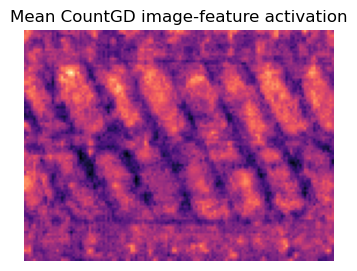

In [7]:
def encode_image(model, image_batch):
    if isinstance(image_batch, torch.Tensor):
        image_batch = list(image_batch)
    samples = nested_tensor_from_tensor_list(image_batch).to(DEVICE)
    with torch.inference_mode():
        features, positions = model.backbone(samples)
        combined = model.combine_features(features)
    assert combined.ndim == 4 and combined.shape[1] == model.hidden_dim
    return features, positions, combined

car_tensor, car_boxes_resized = preprocess_case(CASES[-1])
IMAGE_FEATURES, IMAGE_POSITIONS, COMBINED_FEATURES = encode_image(MODEL, car_tensor.unsqueeze(0))
print("combined image features:", tuple(COMBINED_FEATURES.shape))
plt.figure(figsize=(6, 3)); plt.imshow(COMBINED_FEATURES[0].mean(0).detach().cpu(), cmap="magma")
plt.title("Mean CountGD image-feature activation"); plt.axis("off"); plt.show()


## Task 2 — Text encoder (15%)

Implement `encode_text` by reproducing CountGD's caption path: tokenize, build special-token attention structures, run BERT, and project the last hidden state to the shared model dimension.

**TODO 2**

- tokenize a caption batch with padding;
- build self-attention masks and position IDs using the repository helper;
- run `model.bert` and `model.feat_map`;
- return encoded prompt tokens and the valid-token mask; and
- identify which columns correspond to real prompt tokens rather than padding.

In [8]:
def encode_text(model, captions):
    tokenized = model.tokenizer(captions, padding="longest", return_tensors="pt").to(DEVICE)
    self_masks, position_ids, _ = generate_masks_with_special_tokens_and_transfer_map(
        tokenized, model.specical_tokens, model.tokenizer)
    tokenized_for_encoder = {k: v for k, v in tokenized.items() if k != "attention_mask"}
    tokenized_for_encoder["attention_mask"] = self_masks
    tokenized_for_encoder["position_ids"] = position_ids
    with torch.inference_mode():
        bert_output = model.bert(**tokenized_for_encoder)
        encoded = model.feat_map(bert_output["last_hidden_state"])
    valid = tokenized.attention_mask.bool()
    return {"encoded_text": encoded, "text_token_mask": valid,
            "position_ids": position_ids, "text_self_attention_masks": self_masks,
            "input_ids": tokenized.input_ids}

TEXT_DICT = encode_text(MODEL, ["car ."])
print("encoded text:", tuple(TEXT_DICT["encoded_text"].shape),
      "valid tokens:", int(TEXT_DICT["text_token_mask"].sum()))


encoded text: (1, 4, 256) valid tokens: 4


### Task 3 — ROIAlign visual exemplar tokens (15%)

Use pixel-space exemplar boxes and `roi_align` with `output_size=(1,1)`, `spatial_scale=1/8`, and `aligned=True`, then reshape the result to `(B,N,D)`.


In [9]:
def extract_exemplar_tokens(combined_features, exemplar_boxes):
    if combined_features.ndim != 4 or len(exemplar_boxes) != combined_features.shape[0]:
        raise ValueError("Expected features (B,D,H,W) and one (N,4) box tensor per image")
    counts = [len(boxes) for boxes in exemplar_boxes]
    if len(set(counts)) != 1 or counts[0] == 0:
        raise ValueError("This exercise expects the same positive exemplar count per image")
    tokens = roi_align(combined_features, boxes=exemplar_boxes, output_size=(1, 1),
                       spatial_scale=1/8, aligned=True).squeeze(-1).squeeze(-1)
    return tokens.reshape(combined_features.shape[0], counts[0], -1)

EXEMPLAR_TOKENS = extract_exemplar_tokens(COMBINED_FEATURES, [car_boxes_resized.to(COMBINED_FEATURES.device)])
print("resized exemplar:", car_boxes_resized.tolist())
print("ROIAlign exemplar token:", tuple(EXEMPLAR_TOKENS.shape))


resized exemplar: [[95.8006591796875, 125.49020385742188, 263.016357421875, 379.9564514160156]]
ROIAlign exemplar token: (1, 1, 256)


### Figure Generation for Orginal ROIAlign visual exempler token


In [10]:
# ============================================================
# Task 3 — ORIGINAL ROIAlign Baseline Evidence
# Does NOT depend on PREDICTIONS / Task 6
# ============================================================

import torch

# ------------------------------------------------------------
# 1. Save baseline ROIAlign values
# ------------------------------------------------------------

BASELINE_BOX = car_boxes_resized.detach().cpu().clone()
BASELINE_TOKEN = EXEMPLAR_TOKENS.detach().cpu().clone()

print("======================================")
print("ORIGINAL TASK 3 — ROIAlign BASELINE")
print("======================================")

print("Number of exemplars :", BASELINE_BOX.shape[0])
print("Padding             : None")
print("Sampling ratio      : Adaptive/default")
print("Output size         : (1, 1)")
print("Spatial scale       : 1/8")
print("Aligned             : True")

print("\nResized exemplar box:")
print(BASELINE_BOX.tolist())

print("\nFinal token shape:")
print(tuple(BASELINE_TOKEN.shape))

print("\nToken statistics")
print("Mean    :", BASELINE_TOKEN.mean().item())
print("Std     :", BASELINE_TOKEN.std().item())
print("L2 norm :", torch.norm(BASELINE_TOKEN).item())


# ------------------------------------------------------------
# 2. Coordinate information
# ------------------------------------------------------------

# Actual preprocessing dimensions
resized_w = 1066
resized_h = 800

# Original car image dimensions
original_w = 612
original_h = 459

# Convert resized-image ROI coordinates back to original image
baseline_original = BASELINE_BOX.clone()

baseline_original[:, [0, 2]] *= original_w / resized_w
baseline_original[:, [1, 3]] *= original_h / resized_h

print("\n======================================")
print("COORDINATE CHECK")
print("======================================")

print("Original image size :", (original_w, original_h))
print("Resized image size  :", (resized_w, resized_h))

print("\nROI in resized-image coordinates:")
print(BASELINE_BOX.tolist())

print("\nROI converted to original-image coordinates:")
print(baseline_original.tolist())

print("\nTask 3 baseline successfully verified.")

ORIGINAL TASK 3 — ROIAlign BASELINE
Number of exemplars : 1
Padding             : None
Sampling ratio      : Adaptive/default
Output size         : (1, 1)
Spatial scale       : 1/8
Aligned             : True

Resized exemplar box:
[[95.8006591796875, 125.49020385742188, 263.016357421875, 379.9564514160156]]

Final token shape:
(1, 1, 256)

Token statistics
Mean    : 0.026974162086844444
Std     : 0.897274374961853
L2 norm : 14.334821701049805

COORDINATE CHECK
Original image size : (612, 459)
Resized image size  : (1066, 800)

ROI in resized-image coordinates:
[[95.8006591796875, 125.49020385742188, 263.016357421875, 379.9564514160156]]

ROI converted to original-image coordinates:
[[55.000003814697266, 72.00000762939453, 151.00001525878906, 218.00001525878906]]

Task 3 baseline successfully verified.


### Task 3 - Improved methods (Combine the 3 methods)

In [11]:
# ============================================================
# Task 3 — ROIAlign Ablation Study
#
# B = 1 exemplar vs 3 real exemplars
# C = 0% padding vs 15% padding
# D = Default/adaptive sampling vs sampling_ratio=4
#
# Purpose:
# Evaluate how different ROIAlign design choices affect the
# extracted exemplar feature representation.
#
# NOTE:
# These are feature-level ablations.
# They are NOT claimed as improvements in counting performance.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torchvision.ops import roi_align


# ============================================================
# 1. Helper functions
# ============================================================

def pad_boxes(boxes, pct=0.15):
    """Add percentage padding around xyxy bounding boxes."""

    boxes = boxes.clone().float()

    w = boxes[:, 2] - boxes[:, 0]
    h = boxes[:, 3] - boxes[:, 1]

    padded = torch.stack([
        boxes[:, 0] - w * pct / 2,
        boxes[:, 1] - h * pct / 2,
        boxes[:, 2] + w * pct / 2,
        boxes[:, 3] + h * pct / 2
    ], dim=1)

    return padded.clamp(min=0)


def roi_tokens(features, boxes, sampling_ratio=-1):
    """
    Extract one 256-D ROIAlign token for every exemplar box.
    """

    tokens = roi_align(
        features,
        boxes=[boxes.to(features.device)],
        output_size=(1, 1),
        spatial_scale=1/8,
        sampling_ratio=sampling_ratio,
        aligned=True
    )

    return tokens.squeeze(-1).squeeze(-1)


def cosine(a, b):
    """Cosine similarity between two feature vectors."""

    return F.cosine_similarity(
        a.reshape(1, -1),
        b.reshape(1, -1)
    ).item()


def feature_difference(a, b):
    """L2 distance between two feature vectors."""

    return torch.norm(a - b).item()


# ============================================================
# 2. Baseline exemplar
# ============================================================

BASELINE_BOX = car_boxes_resized.detach().clone().float()

baseline_token = roi_tokens(
    COMBINED_FEATURES,
    BASELINE_BOX,
    sampling_ratio=-1
)

print("======================================")
print("TASK 3 — ROIAlign ABLATION STUDY")
print("======================================")

print("\nBaseline configuration")
print("Number of exemplars :", BASELINE_BOX.shape[0])
print("Padding             : 0%")
print("Sampling ratio      : Adaptive/default")
print("Baseline box        :", BASELINE_BOX.tolist())
print("Token shape         :", tuple(baseline_token.shape))


# ============================================================
# B — 1 EXEMPLAR vs 3 REAL EXEMPLARS
# ============================================================

REAL_CAR_BOXES_RESIZED = torch.tensor([
    [113.8562, 139.4336, 262.7451, 357.2985],
    [385.3595, 400.8715, 534.2484, 636.1656],
    [674.3791, 392.1569, 823.2680, 618.7364]
], dtype=torch.float32)


three_tokens = roi_tokens(
    COMBINED_FEATURES,
    REAL_CAR_BOXES_RESIZED,
    sampling_ratio=-1
)


# Pairwise similarity between the three exemplar features

sim_12 = cosine(
    three_tokens[0],
    three_tokens[1]
)

sim_13 = cosine(
    three_tokens[0],
    three_tokens[2]
)

sim_23 = cosine(
    three_tokens[1],
    three_tokens[2]
)

mean_three_similarity = np.mean([
    sim_12,
    sim_13,
    sim_23
])


print("\n======================================")
print("B — NUMBER OF EXEMPLARS")
print("======================================")

print("Baseline             : 1 exemplar")
print("Modified             : 3 real exemplars")

print("Baseline token shape :", tuple(baseline_token.shape))
print("3-exemplar shape     :", tuple(three_tokens.shape))

print(f"\nCar 1 vs Car 2 cosine : {sim_12:.6f}")
print(f"Car 1 vs Car 3 cosine : {sim_13:.6f}")
print(f"Car 2 vs Car 3 cosine : {sim_23:.6f}")

print(
    f"Mean pairwise cosine  : "
    f"{mean_three_similarity:.6f}"
)


# ============================================================
# C — 0% PADDING vs 15% PADDING
# ============================================================

padded_box = pad_boxes(
    BASELINE_BOX,
    pct=0.15
)


token_no_padding = roi_tokens(
    COMBINED_FEATURES,
    BASELINE_BOX,
    sampling_ratio=-1
)


token_padding = roi_tokens(
    COMBINED_FEATURES,
    padded_box,
    sampling_ratio=-1
)


padding_similarity = cosine(
    token_no_padding[0],
    token_padding[0]
)


padding_difference = feature_difference(
    token_no_padding[0],
    token_padding[0]
)


print("\n======================================")
print("C — EXEMPLAR PADDING")
print("======================================")

print("Baseline padding : 0%")
print("Modified padding : 15%")

print("\nOriginal box:")
print(BASELINE_BOX.tolist())

print("\n15% padded box:")
print(padded_box.tolist())

print(
    f"\nCosine similarity  : "
    f"{padding_similarity:.6f}"
)

print(
    f"L2 feature difference: "
    f"{padding_difference:.6f}"
)


# ============================================================
# D — DEFAULT SAMPLING vs sampling_ratio=4
# ============================================================

token_default = roi_tokens(
    COMBINED_FEATURES,
    BASELINE_BOX,
    sampling_ratio=-1
)


token_dense = roi_tokens(
    COMBINED_FEATURES,
    BASELINE_BOX,
    sampling_ratio=4
)


sampling_similarity = cosine(
    token_default[0],
    token_dense[0]
)


sampling_difference = feature_difference(
    token_default[0],
    token_dense[0]
)


print("\n======================================")
print("D — ROIAlign SAMPLING")
print("======================================")

print("Baseline sampling : Adaptive/default")
print("Modified sampling : sampling_ratio=4")

print(
    f"\nCosine similarity  : "
    f"{sampling_similarity:.6f}"
)

print(
    f"L2 feature difference: "
    f"{sampling_difference:.6f}"
)


# ============================================================
# 3. Summary Table
# ============================================================

summary = pd.DataFrame({

    "Ablation": [
        "Number of exemplars",
        "Exemplar padding",
        "ROIAlign sampling"
    ],

    "Baseline": [
        "1 exemplar",
        "0%",
        "Adaptive/default"
    ],

    "Modified": [
        "3 real exemplars",
        "15%",
        "sampling_ratio=4"
    ],

    "Feature-level evidence": [
        (
            f"Mean pairwise cosine = "
            f"{mean_three_similarity:.4f}"
        ),

        (
            f"Cosine = {padding_similarity:.4f}, "
            f"L2 = {padding_difference:.3f}"
        ),

        (
            f"Cosine = {sampling_similarity:.4f}, "
            f"L2 = {sampling_difference:.3f}"
        )
    ]
})


print("\n======================================")
print("ROIAlign ABLATION SUMMARY")
print("======================================")

display(summary)


# ============================================================
# 4. Interpretation
# ============================================================

print("\n======================================")
print("INTERPRETATION")
print("======================================")

print(
    "B: Multiple exemplars provide several visual feature "
    "representations of the target object."
)

print(
    "C: Adding 15% padding changes the extracted feature "
    "representation by including more surrounding context."
)

print(
    "D: Changing the ROIAlign sampling ratio produces only "
    "a small change in the extracted feature representation."
)

print(
    "\nThese results describe feature-level sensitivity only. "
    "They do not demonstrate an improvement in downstream "
    "counting performance."
)

TASK 3 — ROIAlign ABLATION STUDY

Baseline configuration
Number of exemplars : 1
Padding             : 0%
Sampling ratio      : Adaptive/default
Baseline box        : [[95.8006591796875, 125.49020385742188, 263.016357421875, 379.9564514160156]]
Token shape         : (1, 256)

B — NUMBER OF EXEMPLARS
Baseline             : 1 exemplar
Modified             : 3 real exemplars
Baseline token shape : (1, 256)
3-exemplar shape     : (3, 256)

Car 1 vs Car 2 cosine : 0.950814
Car 1 vs Car 3 cosine : 0.941743
Car 2 vs Car 3 cosine : 0.966096
Mean pairwise cosine  : 0.952884

C — EXEMPLAR PADDING
Baseline padding : 0%
Modified padding : 15%

Original box:
[[95.8006591796875, 125.49020385742188, 263.016357421875, 379.9564514160156]]

15% padded box:
[[83.25948333740234, 106.40523529052734, 275.5575256347656, 399.0414123535156]]

Cosine similarity  : 0.996313
L2 feature difference: 1.230024

D — ROIAlign SAMPLING
Baseline sampling : Adaptive/default
Modified sampling : sampling_ratio=4

Cosine sim

,Ablation,Baseline,Modified,Feature-level evidence
0,Number of exemplars,1 exemplar,3 real exemplars,Mean pairwise cosine = 0.9529
1,Exemplar padding,0%,15%,"Cosine = 0.9963, L2 = 1.230"
2,ROIAlign sampling,Adaptive/default,sampling_ratio=4,"Cosine = 0.9984, L2 = 0.802"



INTERPRETATION
B: Multiple exemplars provide several visual feature representations of the target object.
C: Adding 15% padding changes the extracted feature representation by including more surrounding context.
D: Changing the ROIAlign sampling ratio produces only a small change in the extracted feature representation.

These results describe feature-level sensitivity only. They do not demonstrate an improvement in downstream counting performance.


#### REPORT FIGURE 3.4.3 — COORDINATE TRANSFORMATION

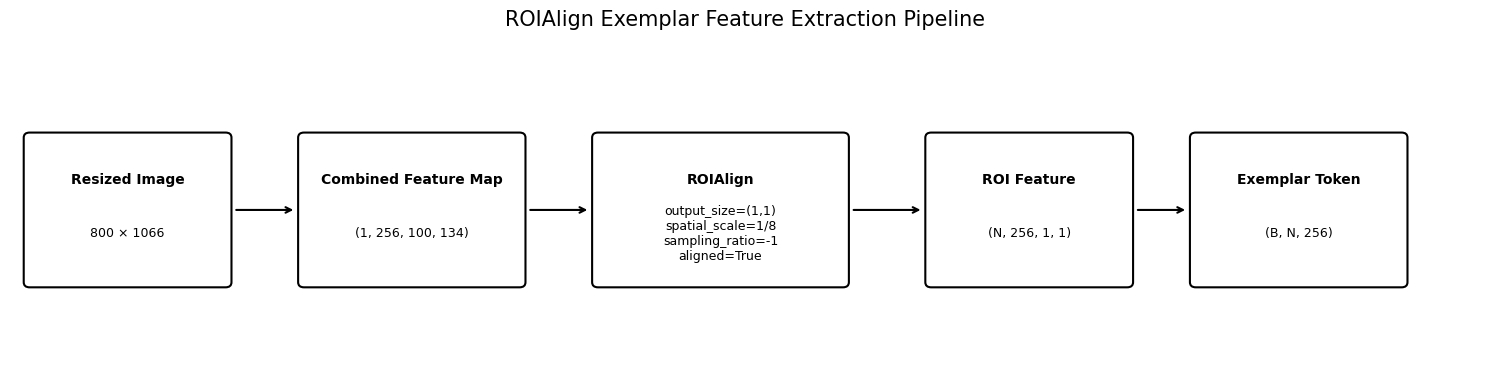

In [12]:
# ============================================================
# REPORT FIGURE 3.4.3 — ROIALIGN WORKFLOW
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(15, 4))

ax.set_xlim(0, 15)
ax.set_ylim(0, 4)
ax.axis("off")

stages = [
    (
        "Resized Image",
        "800 × 1066"
    ),
    (
        "Combined Feature Map",
        str(tuple(COMBINED_FEATURES.shape))
    ),
    (
        "ROIAlign",
        "output_size=(1,1)\n"
        "spatial_scale=1/8\n"
        "sampling_ratio=-1\n"
        "aligned=True"
    ),
    (
        "ROI Feature",
        "(N, 256, 1, 1)"
    ),
    (
        "Exemplar Token",
        "(B, N, 256)"
    )
]

x_positions = [
    0.2,
    3.0,
    6.0,
    9.4,
    12.1
]

widths = [
    2.0,
    2.2,
    2.5,
    2.0,
    2.1
]

for (title, subtitle), x, width in zip(
    stages,
    x_positions,
    widths
):

    box = FancyBboxPatch(
        (x, 1.15),
        width,
        1.7,
        boxstyle="round,pad=0.06",
        linewidth=1.5,
        facecolor="white"
    )

    ax.add_patch(box)

    ax.text(
        x + width / 2,
        2.35,
        title,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        x + width / 2,
        1.72,
        subtitle,
        ha="center",
        va="center",
        fontsize=9
    )


# Arrows
for i in range(len(x_positions) - 1):

    start = x_positions[i] + widths[i]
    end = x_positions[i + 1]

    ax.annotate(
        "",
        xy=(end - 0.08, 2),
        xytext=(start + 0.08, 2),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5
        )
    )


ax.set_title(
    "ROIAlign Exemplar Feature Extraction Pipeline",
    fontsize=15,
    pad=10
)

plt.tight_layout()

plt.savefig(
    "report_3_4_3_roi_pipeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### REPORT FIGURE 3.4.4 — ACTUAL TENSOR SHAPES

In [13]:
# ============================================================
# REPORT DATA 3.4.4 — ACTUAL TENSOR SHAPES
# ============================================================

from torchvision.ops import roi_align
import pandas as pd

# Raw ROIAlign output BEFORE squeeze
raw_roi = roi_align(
    COMBINED_FEATURES,
    boxes=[BASELINE_BOX.to(COMBINED_FEATURES.device)],
    output_size=(1, 1),
    spatial_scale=1/8,
    sampling_ratio=-1,
    aligned=True
)

# Same processing as roi_tokens()
roi_token = raw_roi.squeeze(-1).squeeze(-1)

# Add batch dimension expected downstream
exemplar_token = roi_token.unsqueeze(0)

print("===================================")
print("ROIAlign TENSOR SHAPES")
print("===================================")

print(
    "Combined feature map :",
    tuple(COMBINED_FEATURES.shape)
)

print(
    "Raw ROIAlign output  :",
    tuple(raw_roi.shape)
)

print(
    "After squeeze        :",
    tuple(roi_token.shape)
)

print(
    "Final exemplar token :",
    tuple(exemplar_token.shape)
)


shape_table = pd.DataFrame({
    "Processing Stage": [
        "Combined feature map",
        "Raw ROIAlign output",
        "ROI token",
        "Final exemplar token"
    ],

    "Tensor Shape": [
        str(tuple(COMBINED_FEATURES.shape)),
        str(tuple(raw_roi.shape)),
        str(tuple(roi_token.shape)),
        str(tuple(exemplar_token.shape))
    ]
})

display(shape_table)

ROIAlign TENSOR SHAPES
Combined feature map : (1, 256, 100, 134)
Raw ROIAlign output  : (1, 256, 1, 1)
After squeeze        : (1, 256)
Final exemplar token : (1, 1, 256)


,Processing Stage,Tensor Shape
0,Combined feature map,"(1, 256, 100, 134)"
1,Raw ROIAlign output,"(1, 256, 1, 1)"
2,ROI token,"(1, 256)"
3,Final exemplar token,"(1, 1, 256)"


In [14]:
# ============================================================
# 3.4.5 — NEGATIVE COORDINATE TEST
# Correct pixel coordinates vs incorrect normalized coordinates
# ============================================================

import torch
import torch.nn.functional as F
from torchvision.ops import roi_align


# ------------------------------------------------------------
# 1. Correct resized-image pixel coordinates
# ------------------------------------------------------------

correct_box = BASELINE_BOX.clone().float()


# ------------------------------------------------------------
# 2. Incorrectly normalized coordinates [0,1]
# Actual resized image size = 1066 × 800
# ------------------------------------------------------------

wrong_box = correct_box.clone()

wrong_box[:, [0, 2]] /= 1066.0
wrong_box[:, [1, 3]] /= 800.0


# ------------------------------------------------------------
# 3. ROIAlign using correct coordinates
# ------------------------------------------------------------

correct_roi = roi_align(
    COMBINED_FEATURES,
    boxes=[correct_box.to(COMBINED_FEATURES.device)],
    output_size=(1, 1),
    spatial_scale=1/8,
    sampling_ratio=-1,
    aligned=True
)

correct_token = correct_roi.squeeze(-1).squeeze(-1)


# ------------------------------------------------------------
# 4. ROIAlign using incorrect normalized coordinates
# ------------------------------------------------------------

wrong_roi = roi_align(
    COMBINED_FEATURES,
    boxes=[wrong_box.to(COMBINED_FEATURES.device)],
    output_size=(1, 1),
    spatial_scale=1/8,
    sampling_ratio=-1,
    aligned=True
)

wrong_token = wrong_roi.squeeze(-1).squeeze(-1)


# ------------------------------------------------------------
# 5. Compare extracted features
# ------------------------------------------------------------

cosine_similarity = F.cosine_similarity(
    correct_token,
    wrong_token,
    dim=1
).item()

l2_difference = torch.norm(
    correct_token - wrong_token
).item()


print("======================================")
print("NEGATIVE COORDINATE TEST")
print("======================================")

print("\nCorrect resized pixel box:")
print(correct_box.tolist())

print("\nIncorrect normalized box:")
print(wrong_box.tolist())

print("\nCorrect token shape:")
print(tuple(correct_token.shape))

print("\nIncorrect token shape:")
print(tuple(wrong_token.shape))

print("\nCosine similarity:")
print(f"{cosine_similarity:.6f}")

print("\nL2 feature difference:")
print(f"{l2_difference:.6f}")

NEGATIVE COORDINATE TEST

Correct resized pixel box:
[[95.8006591796875, 125.49020385742188, 263.016357421875, 379.9564514160156]]

Incorrect normalized box:
[[0.08986928313970566, 0.1568627506494522, 0.24673204123973846, 0.4749455749988556]]

Correct token shape:
(1, 256)

Incorrect token shape:
(1, 256)

Cosine similarity:
0.693642

L2 feature difference:
11.003036


### Task 4 — Similarity matrix calculation (15%)

Compute query–prompt dot products, mask padded prompt columns with `-inf`, and visualize the valid part of the similarity matrix.


similarity matrix: (1, 13400, 5)


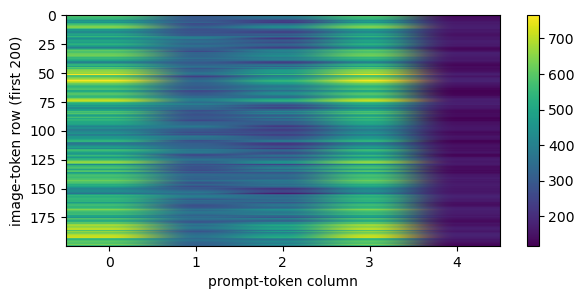

In [15]:
def calculate_similarity_matrix(query_features, prompt_features, prompt_mask):
    if query_features.ndim != 3 or prompt_features.ndim != 3:
        raise ValueError("Expected query (B,N,D) and prompt (B,T,D)")
    if query_features.shape[0] != prompt_features.shape[0] or query_features.shape[-1] != prompt_features.shape[-1]:
        raise ValueError("Batch and feature dimensions must agree")
    if prompt_mask.shape != prompt_features.shape[:2]:
        raise ValueError("Prompt mask must have shape (B,T)")
    logits = query_features @ prompt_features.transpose(-1, -2)
    return logits.masked_fill(~prompt_mask[:, None, :], float("-inf"))

IMAGE_TOKENS = COMBINED_FEATURES.flatten(2).transpose(1, 2)
PROMPT_TOKENS = torch.cat([TEXT_DICT["encoded_text"].to(IMAGE_TOKENS.device), EXEMPLAR_TOKENS], dim=1)
PROMPT_MASK = torch.cat([TEXT_DICT["text_token_mask"].to(IMAGE_TOKENS.device),
                         torch.ones((1, EXEMPLAR_TOKENS.shape[1]), dtype=torch.bool, device=IMAGE_TOKENS.device)], dim=1)
SIMILARITY = calculate_similarity_matrix(IMAGE_TOKENS, PROMPT_TOKENS, PROMPT_MASK)
print("similarity matrix:", tuple(SIMILARITY.shape))
plt.figure(figsize=(7, 3)); plt.imshow(SIMILARITY[0, :200].detach().cpu(), aspect="auto", cmap="viridis")
plt.xlabel("prompt-token column"); plt.ylabel("image-token row (first 200)"); plt.colorbar(); plt.show()


### Task 5 — Top-K encoder proposal selection (15%)

Reduce each proposal to its strongest prompt score, apply `topk` over proposals, and report the winning proposal IDs and prompt IDs.


In [16]:
def select_topk(similarity, k):
    if similarity.ndim != 3 or not 1 <= k <= similarity.shape[1]:
        raise ValueError("Expected (B,N,T) similarities and 1 <= k <= N")
    proposal_scores, prompt_ids = similarity.max(dim=-1)
    scores, proposal_ids = torch.topk(proposal_scores, k, dim=1)
    selected_prompt_ids = torch.gather(prompt_ids, 1, proposal_ids)
    return scores, proposal_ids, selected_prompt_ids

TOPK_SCORES, TOPK_PROPOSALS, TOPK_PROMPTS = select_topk(SIMILARITY, 10)
print("top-K proposal IDs:", TOPK_PROPOSALS.tolist())
print("winning prompt IDs:", TOPK_PROMPTS.tolist())


top-K proposal IDs: [[13396, 13395, 13394, 657, 13038, 326, 13257, 13172, 13241, 13261]]
winning prompt IDs: [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


### Task 6 — Shared integration experiment and results (25%)

Run the official model on all four prompt cases and include counts, localization plots at threshold `0.23`, component shapes, one ablation, runtime/hardware, and one failure case.

**TODO 6A — Prompt sensitivity experiment**

- create new text-only cases without changing the source images: `women → man` and `car → yellow car`;
- run each changed prompt through the live CountGD model using the same preprocessing and post-processing;
- report the changed captions, counts, scores, boxes, and localization plots; and
- compare each changed-prompt result with its original-prompt baseline.

Changed prompts require a live model forward pass. Run fresh inference for `man` and `yellow car`; do not reuse predictions from another query.


In [17]:
import os
import sys
import torch

ops_path = r"C:\Users\Agathiyan\SC5006\MultiModalCounting-master\vendor\countgd\models\GroundingDINO\ops"

os.add_dll_directory(r"C:\Education\SOFTWARE\Lib\site-packages\torch\lib")
os.add_dll_directory(r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8\bin")

sys.path.insert(0, ops_path)

import MultiScaleDeformableAttention as _C

print("Extension loaded successfully")
print("Has forward:", hasattr(_C, "ms_deform_attn_forward"))

Extension loaded successfully
Has forward: True


In [18]:
import vendor.countgd.models.GroundingDINO.ms_deform_attn as msda

msda._C = _C

print("GroundingDINO _C fixed:", hasattr(msda._C, "ms_deform_attn_forward"))

GroundingDINO _C fixed: True


In [19]:
import sys
import MultiScaleDeformableAttention as _C

patched = []

for name, module in list(sys.modules.items()):
    if module is not None and name.endswith("ms_deform_attn"):
        module._C = _C
        patched.append(name)

print("Patched modules:")
for name in patched:
    print(" -", name)

print("Forward available:", hasattr(_C, "ms_deform_attn_forward"))

Patched modules:
 - models.GroundingDINO.ms_deform_attn
 - vendor.countgd.models.GroundingDINO.ms_deform_attn
Forward available: True


women_text 'women' LIVE (900, 256) (900, 4) count= 5 time=1.17s
car_text 'car' LIVE (900, 256) (900, 4) count= 16 time=0.60s
car_exemplar '' LIVE (900, 256) (900, 4) count= 16 time=0.54s
car_multimodal 'car' LIVE (900, 256) (900, 4) count= 16 time=0.56s


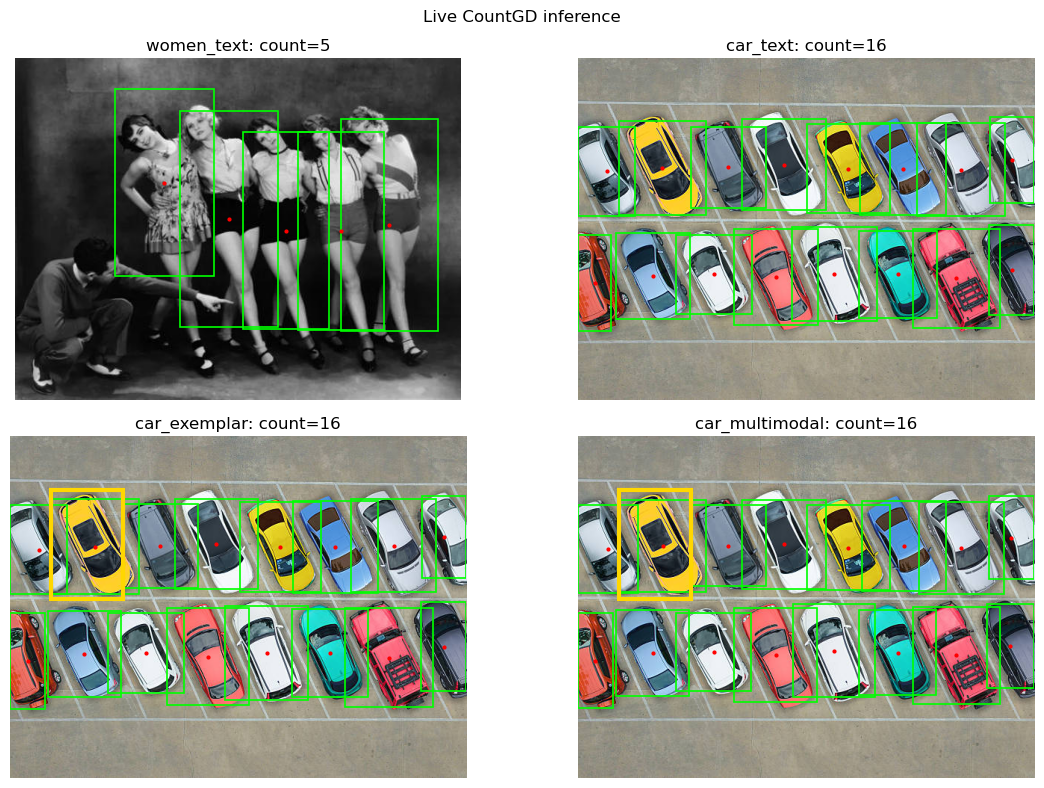

In [20]:
# Task 6 reuses prepare_case and preprocess_case from Section 0.
# The official forward pass internally executes the components studied in Tasks 1–5.
def run_countgd(model, image_name, query="", exemplar_boxes=()):
    case_name = f"{Path(image_name).stem}_{query or 'exemplar'}".replace(" ", "_")
    case = prepare_case(case_name, image_name, text=query, boxes=exemplar_boxes)
    image_tensor, boxes = preprocess_case(case)
    model.drop_text = case["mode"] == "exemplar only"
    with torch.inference_mode():
        output = model(
            image_tensor.unsqueeze(0).to(DEVICE),
            [boxes.to(DEVICE)],
            [torch.tensor([0], device=DEVICE)],
            captions=[case["caption"]],
        )
    assert tuple(output["pred_logits"].shape[1:]) == (900, 256)
    assert tuple(output["pred_boxes"].shape[1:]) == (900, 4)
    raw = {
        "confidences": output["pred_logits"][0].sigmoid().cpu().numpy().astype(np.float32),
        "boxes": output["pred_boxes"][0].cpu().numpy().astype(np.float32),
        "image_size": (case["image"].height, case["image"].width),
    }
    return case, raw

def postprocess_countgd(raw, threshold=0.23):
    confidences, boxes = raw["confidences"], raw["boxes"]
    finite = np.isfinite(confidences).all(1) & np.isfinite(boxes).all(1)
    scores = np.where(finite[:, None], confidences, -np.inf).max(1)
    keep = finite & (scores > threshold)
    scores, boxes = scores[keep], boxes[keep]
    h, w = raw["image_size"]
    cx, cy, bw, bh = boxes.T
    xyxy = np.column_stack([(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h])
    xyxy[:, [0, 2]] = np.clip(xyxy[:, [0, 2]], 0, w-1)
    xyxy[:, [1, 3]] = np.clip(xyxy[:, [1, 3]], 0, h-1)
    centers = np.column_stack([(xyxy[:, 0]+xyxy[:, 2])/2, (xyxy[:, 1]+xyxy[:, 3])/2])
    return {"scores": scores, "boxes": xyxy, "centers": centers, "count": len(scores)}

def predict_countgd(image_name, query="", exemplar_boxes=(), threshold=0.23):
    case, raw = run_countgd(MODEL, image_name, query, exemplar_boxes)
    return {"case": case, "raw": raw, "result": postprocess_countgd(raw, threshold)}

# Text inference needs only the image filename and query. Boxes are optional for exemplar modes.
REQUESTS = [
    ("women_text", "women.jpg", "women", ()),
    ("car_text", "car.jpg", "car", ()),
    ("car_exemplar", "car.jpg", "", [[55, 72, 151, 218]]),
    ("car_multimodal", "car.jpg", "car", [[55, 72, 151, 218]]),
]

PREDICTIONS = {}
for name, image_name, query, exemplar_boxes in REQUESTS:
    t0 = time.time()
    BASELINE_THRESHOLD = 0.23
    prediction = predict_countgd(image_name, query, exemplar_boxes, threshold=BASELINE_THRESHOLD)
    PREDICTIONS[name] = prediction
    print(name, repr(query), "LIVE", prediction["raw"]["confidences"].shape,
          prediction["raw"]["boxes"].shape, "count=", prediction["result"]["count"],
          f"time={time.time()-t0:.2f}s")

# Keep these aliases for the prompt-sensitivity experiment below.
RAW = {name: value["raw"] for name, value in PREDICTIONS.items()}
RESULTS = {name: value["result"] for name, value in PREDICTIONS.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, prediction) in zip(axes.flat, PREDICTIONS.items()):
    case, result = prediction["case"], prediction["result"]
    ax.imshow(case["image"])
    for score, (x1, y1, x2, y2), (x, y) in zip(result["scores"], result["boxes"], result["centers"]):
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="lime", lw=1.2))
        ax.plot(x, y, "r.", ms=4)
    for x1, y1, x2, y2 in case["boxes"]:
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="gold", lw=3))
    ax.set_title(f"{name}: count={result['count']}")
    ax.axis("off")
fig.suptitle("Live CountGD inference")
fig.tight_layout()
fig.savefig(OUTPUT / "official_countgd_car_women_tests.png", dpi=170, bbox_inches="tight")
plt.show()


women_as_man 'man .' tokens= ['man'] count= 1
car_as_yellow_car 'yellow car .' tokens= ['yellow', 'car'] count= 2


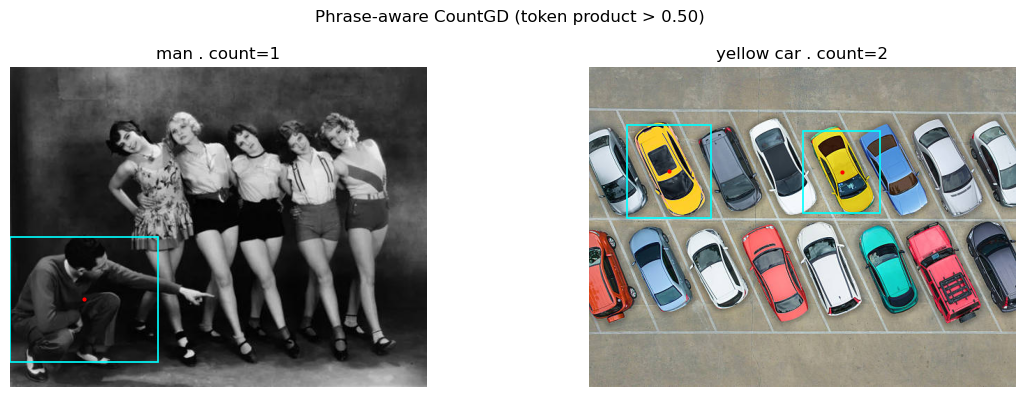

In [21]:
PROMPT_VARIANTS = [
    prepare_case("women_as_man", "women.jpg", text="man"),
    prepare_case("car_as_yellow_car", "car.jpg", text="yellow car"),
]

def phrase_token_indices(model, caption):
    encoded = model.tokenizer(caption)
    tokens = model.tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    ignored = set(model.tokenizer.all_special_tokens) | {".", ",", ";", ":", "!", "?"}
    indices = [index for index, token in enumerate(tokens) if token not in ignored]
    if not indices:
        raise ValueError(f"No meaningful text tokens found in {caption!r}")
    return indices, [tokens[index] for index in indices]

def postprocess_phrase_query(raw, model, caption, threshold=0.50):
    indices, tokens = phrase_token_indices(model, caption)
    phrase_scores = raw["confidences"][:, indices].prod(axis=1, dtype=np.float32)
    phrase_raw = {**raw, "confidences": phrase_scores[:, None]}
    result = postprocess_countgd(phrase_raw, threshold)
    result["phrase_tokens"] = tokens
    return result

def evaluate_prompt_variants(model, prompt_cases, threshold=0.50):
    if model is None:
        raise RuntimeError("Changed prompts require fresh live-model inference.")
    evaluated = {}
    for case in prompt_cases:
        query = case["caption"][:-2] if case["caption"].endswith(" .") else case["caption"]
        _, raw = run_countgd(model, case["image_name"], query, case["boxes"])
        result = postprocess_phrase_query(raw, model, case["caption"], threshold)
        evaluated[case["name"]] = {"raw": raw, "result": result}
    return evaluated

PHRASE_THRESHOLD = 0.50
PROMPT_RESULTS = evaluate_prompt_variants(MODEL, PROMPT_VARIANTS, PHRASE_THRESHOLD)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, case in zip(axes, PROMPT_VARIANTS):
    result = PROMPT_RESULTS[case["name"]]["result"]
    ax.imshow(case["image"])
    for score, (x1, y1, x2, y2), (x, y) in zip(
        result["scores"], result["boxes"], result["centers"]
    ):
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="cyan", lw=1.2))
        ax.plot(x, y, "r.", ms=4)
    ax.set_title(f"{case['caption']} count={result['count']}")
    ax.axis("off")
    print(case["name"], repr(case["caption"]),
          "tokens=", result["phrase_tokens"], "count=", result["count"])
fig.suptitle(f"Phrase-aware CountGD (token product > {PHRASE_THRESHOLD:.2f})")
fig.tight_layout()
fig.savefig(OUTPUT / "countgd_changed_text_prompts.png", dpi=170, bbox_inches="tight")
plt.show()

FAILURE CASE: "red car"
Threshold       : 0.23
Reference count : 3
Predicted count : 16
Absolute error  : 13


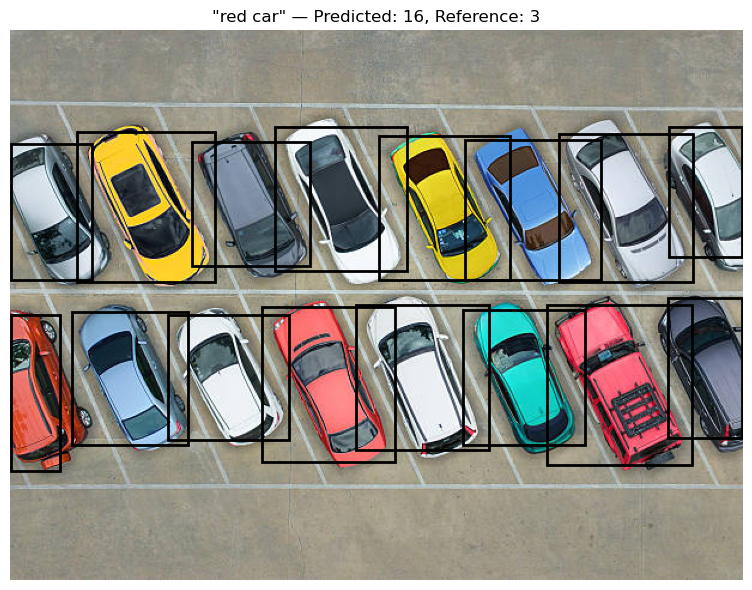

In [31]:
# ============================================================
# FAILURE CASE — "red car" at threshold = 0.23
# ============================================================

RED_CAR_REFERENCE = 3
BASELINE_THRESHOLD = 0.23

# Run text-only inference
red_car_prediction = predict_countgd(
    "car.jpg",
    query="red car",
    exemplar_boxes=(),
    threshold=BASELINE_THRESHOLD
)

red_car_result = red_car_prediction["result"]
red_car_case = red_car_prediction["case"]


# ============================================================
# QUANTITATIVE RESULT
# ============================================================

print("=" * 55)
print('FAILURE CASE: "red car"')
print("=" * 55)
print("Threshold       :", BASELINE_THRESHOLD)
print("Reference count :", RED_CAR_REFERENCE)
print("Predicted count :", red_car_result["count"])
print(
    "Absolute error  :",
    abs(red_car_result["count"] - RED_CAR_REFERENCE)
)


# ============================================================
# VISUALISE DETECTIONS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(red_car_case["image"])

# Draw predicted bounding boxes
for x1, y1, x2, y2 in red_car_result["boxes"]:

    ax.add_patch(
        Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
    )

ax.set_title(
    f'"red car" — Predicted: {red_car_result["count"]}, '
    f'Reference: {RED_CAR_REFERENCE}'
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT / "red_car_failure_023.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Query tokens: ['red', 'car']
Token indices: [1, 2]


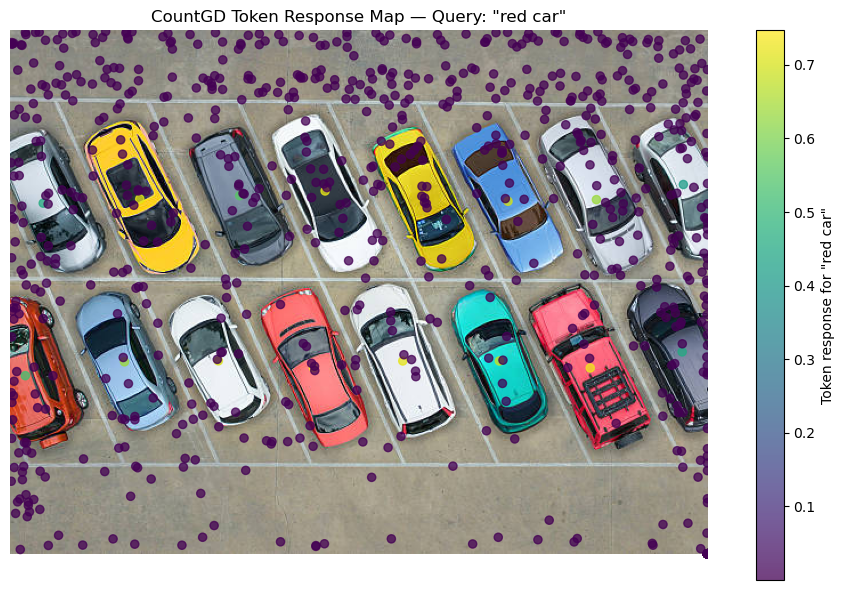

In [27]:
# ============================================================
# FAILURE ANALYSIS — "red car" TOKEN RESPONSE MAP
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Raw output from the existing "red car" inference
raw = red_car_prediction["raw"]

# Find the meaningful token indices for "red car"
token_indices, token_names = phrase_token_indices(
    MODEL,
    red_car_case["caption"]
)

print("Query tokens:", token_names)
print("Token indices:", token_indices)

# Confidence of each proposal for the phrase "red car"
# Product combines the response to "red" and "car"
phrase_scores = raw["confidences"][:, token_indices].prod(
    axis=1,
    dtype=np.float32
)

# Proposal boxes are normalized cx, cy, w, h
proposal_boxes = raw["boxes"]

h, w = raw["image_size"]

# Convert proposal centres to image coordinates
centers_x = proposal_boxes[:, 0] * w
centers_y = proposal_boxes[:, 1] * h

# ============================================================
# VISUALISE TOKEN RESPONSE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(red_car_case["image"])

scatter = ax.scatter(
    centers_x,
    centers_y,
    c=phrase_scores,
    s=35,
    cmap="viridis",
    alpha=0.75
)

plt.colorbar(
    scatter,
    ax=ax,
    label='Token response for "red car"'
)

ax.set_title(
    'CountGD Token Response Map — Query: "red car"'
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT / "red_car_token_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

REMEDY TEST: "red car" + red exemplar
Threshold        : 0.23
Reference count  : 3
Text-only count  : 16
Multimodal count : 16
Text-only error  : 13
Multimodal error : 13


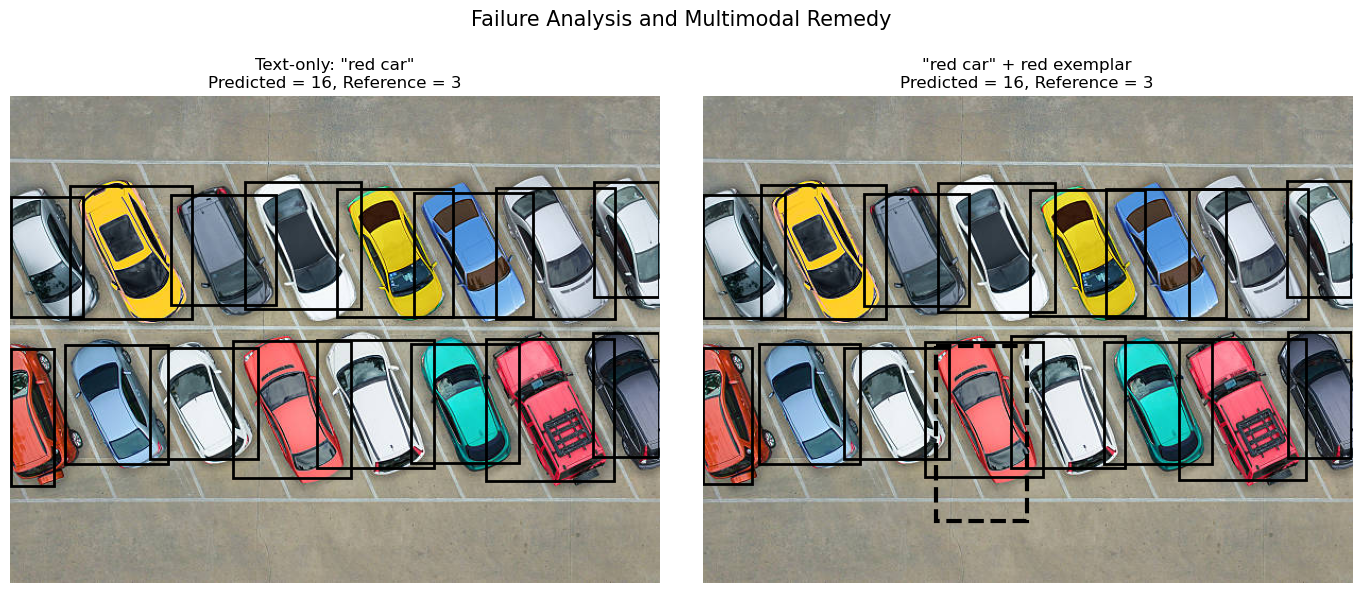

In [30]:
# ============================================================
# REMEDY TEST — "red car" + red-car exemplar
# ============================================================

RED_CAR_REFERENCE = 3
BASELINE_THRESHOLD = 0.23

# Red-car exemplar from the bottom row of car.jpg
RED_CAR_EXEMPLAR = [[220, 235, 305, 400]]

# Run multimodal inference
red_car_multimodal = predict_countgd(
    "car.jpg",
    query="red car",
    exemplar_boxes=RED_CAR_EXEMPLAR,
    threshold=BASELINE_THRESHOLD
)

remedy_result = red_car_multimodal["result"]
remedy_case = red_car_multimodal["case"]


# ============================================================
# 1. QUANTITATIVE COMPARISON
# ============================================================

print("=" * 60)
print('REMEDY TEST: "red car" + red exemplar')
print("=" * 60)

print("Threshold        :", BASELINE_THRESHOLD)
print("Reference count  :", RED_CAR_REFERENCE)
print("Text-only count  :", red_car_result["count"])
print("Multimodal count :", remedy_result["count"])

print(
    "Text-only error  :",
    abs(red_car_result["count"] - RED_CAR_REFERENCE)
)

print(
    "Multimodal error :",
    abs(remedy_result["count"] - RED_CAR_REFERENCE)
)


# ============================================================
# 2. SIDE-BY-SIDE COMPARISON
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

experiments = [
    (
        'Text-only: "red car"',
        red_car_case,
        red_car_result
    ),
    (
        '"red car" + red exemplar',
        remedy_case,
        remedy_result
    )
]

for ax, (title, case, result) in zip(axes, experiments):

    ax.imshow(case["image"])

    # Predicted bounding boxes
    for x1, y1, x2, y2 in result["boxes"]:

        ax.add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2
            )
        )

    # Show exemplar as dashed box
    if len(case["boxes"]) > 0:

        for x1, y1, x2, y2 in case["boxes"]:

            ax.add_patch(
                Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=3,
                    linestyle="--"
                )
            )

    ax.set_title(
        f"{title}\n"
        f"Predicted = {result['count']}, "
        f"Reference = {RED_CAR_REFERENCE}"
    )

    ax.axis("off")


# ============================================================
# 3. SAVE FINAL FIGURE
# ============================================================

fig.suptitle(
    'Failure Analysis and Multimodal Remedy',
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig(
    OUTPUT / "red_car_remedy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

MODALITY ABLATION — THRESHOLD = 0.23


,Method,Predicted Count,Reference Count,Absolute Error
0,Text-only,16,16,0
1,Exemplar-only,16,16,0
2,Multimodal,16,16,0


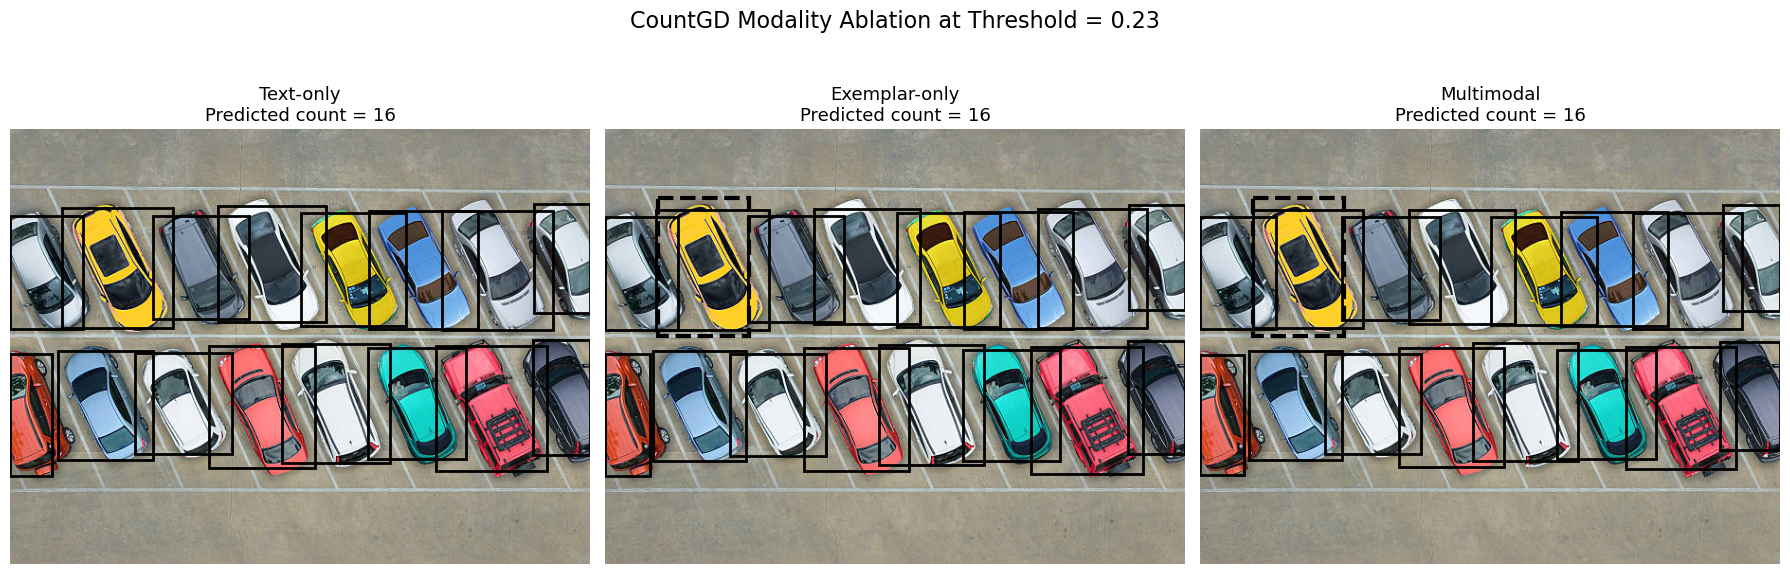

In [29]:
# ============================================================
# MODALITY ABLATION — THRESHOLD = 0.23
# Text-only vs Exemplar-only vs Multimodal
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

REFERENCE_COUNT = 16
BASELINE_THRESHOLD = 0.23

car_cases = {
    "Text-only": "car_text",
    "Exemplar-only": "car_exemplar",
    "Multimodal": "car_multimodal"
}


# ============================================================
# 1. QUANTITATIVE COUNT COMPARISON
# ============================================================

rows = []

for label, key in car_cases.items():

    result = PREDICTIONS[key]["result"]
    count = int(result["count"])

    rows.append({
        "Method": label,
        "Predicted Count": count,
        "Reference Count": REFERENCE_COUNT,
        "Absolute Error": abs(count - REFERENCE_COUNT)
    })

comparison = pd.DataFrame(rows)

print("=" * 65)
print("MODALITY ABLATION — THRESHOLD = 0.23")
print("=" * 65)

display(comparison)


# ============================================================
# 2. SIDE-BY-SIDE BOUNDING-BOX COMPARISON
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

for ax, (label, key) in zip(axes, car_cases.items()):

    data = PREDICTIONS[key]

    case = data["case"]
    result = data["result"]

    image = case["image"]
    boxes = np.asarray(result["boxes"])
    count = int(result["count"])

    ax.imshow(image)

    # ----------------------------------------
    # Predicted bounding boxes
    # ----------------------------------------

    for box in boxes:

        x1, y1, x2, y2 = box

        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

    # ----------------------------------------
    # Exemplar box
    # Only shown for exemplar and multimodal
    # ----------------------------------------

    if len(case["boxes"]) > 0:

        for box in case["boxes"]:

            x1, y1, x2, y2 = box

            exemplar_rect = Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=3,
                linestyle="--"
            )

            ax.add_patch(exemplar_rect)

    ax.set_title(
        f"{label}\nPredicted count = {count}",
        fontsize=13
    )

    ax.axis("off")


# ============================================================
# 3. FINAL FIGURE
# ============================================================

fig.suptitle(
    "CountGD Modality Ablation at Threshold = 0.23",
    fontsize=16
)

# Leave space between main title and subplot titles
plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.savefig(
    "car_modality_ablation_023.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()